# Plane integral of charge density alon z
## We assume the cube file is in a orthogonal cell (a,b,c)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import physical_constants
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
bohr_to_ang = physical_constants["Bohr radius"][0] * 1e10  # Å

# path to cube file to be displayed

In [2]:
cube="/home/jovyan/Downloads/charge.cube"
# cube2="/Users/cpi/TRASH/baderT2T4/T2/charge.cube"
# slab4="/Users/cpi/TRASH/baderT2T4/T4/slab.cube"
# slab2="/Users/cpi/TRASH/baderT2T4/T2/slab.cube"
# mol4="/Users/cpi/TRASH/baderT2T4/T4/mol.cube"
# mol2="/Users/cpi/TRASH/baderT2T4/T2/mol.cube"

In [3]:
def read_cube_full(filename):
    """
    Read a Gaussian cube file.

    Returns
    -------
    header_lines : list[str]
        Original header lines up to atom list (used for writing)
    atom_lines : list[str]
        Atom specification lines
    rho : ndarray (nx, ny, nz)
        Volumetric data (e / bohr^3)
    grid_shape : tuple
        (nx, ny, nz)
    """
    with open(filename) as f:
        lines = f.readlines()

    # First two comment lines
    header_lines = lines[:2]

    # Origin + grid
    natoms = int(lines[2].split()[0])
    grid_lines = lines[2:6]

    header_lines += grid_lines

    nx = int(grid_lines[1].split()[0])
    ny = int(grid_lines[2].split()[0])
    nz = int(grid_lines[3].split()[0])

    atom_lines = lines[6:6 + natoms]

    data_lines = lines[6 + natoms:]

    raw = []
    for line in data_lines:
        raw.extend(map(float, line.split()))

    rho = np.array(raw).reshape((nx, ny, nz))

    return header_lines, atom_lines, rho, (nx, ny, nz)


In [4]:
def z_charge_density_profile(header_lines, rho, bohr_to_ang):
    """
    Return lambda(z) such that integral lambda(z) dz = total charge.

    Assumes the 3rd cube axis is the physical z direction.

    Returns
    -------
    z_ang : ndarray
        z coordinate in Å
    lambda_z_ang : ndarray
        Charge per unit length in e/Å
    """

    origin_tokens = header_lines[2].split()
    z0_bohr = float(origin_tokens[3])

    xgrid_tokens = header_lines[3].split()
    ygrid_tokens = header_lines[4].split()
    zgrid_tokens = header_lines[5].split()

    nx = int(xgrid_tokens[0])
    ny = int(ygrid_tokens[0])
    nz = int(zgrid_tokens[0])

    vx = np.array(list(map(float, xgrid_tokens[1:4])))   # bohr
    vy = np.array(list(map(float, ygrid_tokens[1:4])))   # bohr
    vz = np.array(list(map(float, zgrid_tokens[1:4])))   # bohr

    dx = np.linalg.norm(vx)   # bohr
    dy = np.linalg.norm(vy)   # bohr
    dz = np.linalg.norm(vz)   # bohr

    # z axis in bohr and Å
    z_bohr = z0_bohr + np.arange(nz) * dz
    z_ang = z_bohr * bohr_to_ang

    # integrate rho over x,y  -> units e/bohr
    lambda_z_bohr = rho.sum(axis=(0, 1)) * dx * dy

    # convert to e/Å so that trapz(lambda_z_ang, z_ang) gives charge in e
    lambda_z_ang = lambda_z_bohr / bohr_to_ang

    return z_ang, lambda_z_ang

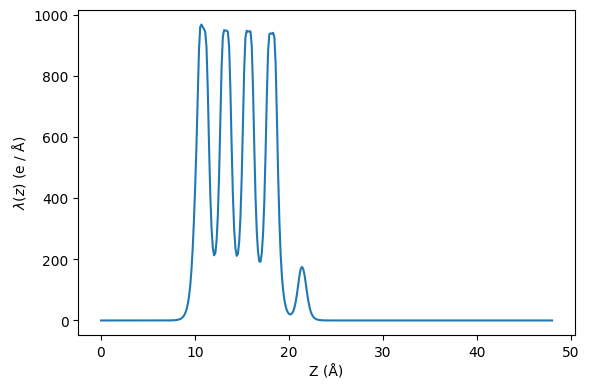

In [5]:
header_lines, atom_lines, rho, shape = read_cube_full(cube)

z_ang, lambda_z_ang = z_charge_density_profile(header_lines, rho, bohr_to_ang)

plt.figure(figsize=(6,4))
plt.plot(z_ang, lambda_z_ang)
plt.xlabel("Z (Å)")
plt.ylabel(r"$\lambda(z)$ (e / Å)")
plt.tight_layout()
plt.show()

# line integral

In [6]:
Q_from_z = np.trapz(lambda_z_ang, z_ang)
print("Integrated charge from z profile:", Q_from_z)

Integrated charge from z profile: 6151.987172571877


# Volume integral

In [7]:
xgrid_tokens = header_lines[3].split()
ygrid_tokens = header_lines[4].split()
zgrid_tokens = header_lines[5].split()

vx = np.array(list(map(float, xgrid_tokens[1:4])))
vy = np.array(list(map(float, ygrid_tokens[1:4])))
vz = np.array(list(map(float, zgrid_tokens[1:4])))

dx = np.linalg.norm(vx)
dy = np.linalg.norm(vy)
dz = np.linalg.norm(vz)

Q_3d = rho.sum() * dx * dy * dz
print("Integrated charge from 3D grid:", Q_3d)

Integrated charge from 3D grid: 6151.987294800336
